# Selección de features — todas las variables, frente al modelo

## Qué responde este notebook

`10_ingenieria_features.ipynb` construyó variables nuevas y verificó que ninguna tiene fuga. Este
notebook responde la pregunta real de la fase: **de todas las variables disponibles — las que ya
existían y las nuevas — ¿cuáles ayudan de verdad a predecir cada uno de los 3 targets?**

No se repite una correlación aislada variable por variable — `06_eda_general.ipynb` ya mostró que
eso puede ser engañoso (la correlación lineal de años de experiencia es ~0, pero la relación real
tiene forma de curva). Se arma una tabla amplia con **todas** las variables candidatas juntas y se
mide cuánto aporta cada una dentro de un modelo simple (no el modelo final — eso es Fase 5), sobre
un split temporal, para los 3 targets. Ahí se resuelve también, con evidencia real y conjunta, si
`last3` y `last5` aportan cada una por separado — la pregunta que se dejó abierta a propósito en
`08_eda_multivariable.ipynb`.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"
MORADO, ROSA = "#7f77dd", "#d4537e"

SEASONS = list(range(2016, 2026))
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]

stats = data.cargar_stats_semanales(SEASONS)
jugadores = data.cargar_jugadores()
calendario = data.cargar_calendario(SEASONS)
depth_hist = data.cargar_depth_charts_historico([s for s in SEASONS if s <= 2024])
qb_titular = data.identificar_qb_titular(stats)
wr = stats[stats["position"] == "WR"].copy()
print("filas WR, 2016-2025:", wr.shape[0])

filas WR, 2016-2025: 23610


## 1. Por qué 2016-2025 y no solo 2024-2025

Toda la EDA de Fase 3 se hizo sobre 2 temporadas (2024-2025). Antes de decidir el rango aquí, se
verifica qué tan atrás hay cobertura real (no nula) de las columnas nativas más importantes —
ampliar el rango sin verificar sería asumir, no comprobar.

In [2]:
for col in ["target_share", "air_yards_share", "wopr", "receiving_epa"]:
    cobertura = wr.groupby("season")[col].apply(lambda s: s.notna().mean())
    print(f"{col}: min {cobertura.min():.3f}, max {cobertura.max():.3f} (2016-2025)")

target_share: min 1.000, max 1.000 (2016-2025)
air_yards_share: min 1.000, max 1.000 (2016-2025)
wopr: min 1.000, max 1.000 (2016-2025)
receiving_epa: min 0.833, max 0.885 (2016-2025)


`target_share`, `air_yards_share` y `wopr` tienen cobertura del 100% en las 10 temporadas —
`receiving_epa` se mantiene entre 83% y 89% en todas, sin una caída específica en años viejos (el
faltante es estructural — semanas sin target atribuible, mismo patrón ya documentado en Fase 3 —
no un problema de antigüedad de los datos). Con esto, se usan las 10 temporadas completas
(2016-2025): un split temporal más amplio da una estimación de importancia más estable que uno de
solo 2 años, y esto es evidencia para una herramienta de *screening*, no el modelo final de
Fase 5.

## 2. Construir la tabla amplia — todo lo de `10_ingenieria_features.ipynb`, en un solo lugar

Se reconstruyen aquí las mismas variables ya verificadas fila por fila en el notebook anterior —
no se repite esa verificación, ya quedó hecha. Además se integra el contexto que Fase 3 calculó
pero nunca leyó por escrito (`rest`, `div_game`, `roof`, `surface`) y el depth chart, que nunca se
había evaluado contra ningún target.

In [3]:
wr = features.calcular_ratios_eficiencia(wr)
wr["racr"] = (wr["receiving_yards"] / wr["receiving_air_yards"]).where(wr["receiving_air_yards"] > 0)
wr = features.acotar_variable(wr, "racr", percentil=0.99)

columnas_base = [
    "receptions", "targets", "receiving_yards", "receiving_air_yards",
    "receiving_yards_after_catch", "receiving_first_downs", "receiving_tds",
    "receiving_2pt_conversions", "receiving_10", "receiving_16", "receiving_20", "receiving_40",
    "target_share", "air_yards_share", "wopr", "receiving_epa", "fantasy_points_ppr",
    "yards_per_target", "catch_rate", "air_yards_per_target", "racr_acotado",
]
wr = features.agregar_promedios_jugador(wr, columnas_base, ventanas=(3, 5))
wr = features.agregar_volatilidad_jugador(wr, ["receiving_yards", "targets"], ventana=5)
wr = features.agregar_edad_experiencia(wr, jugadores)
wr = features.agregar_experiencia_no_lineal(wr)
wr = features.agregar_draft_pick(wr, jugadores)
wr = features.agregar_ofensiva_equipo(wr, columnas=("receiving_yards", "targets"), ventanas=(3, 5))
wr = features.agregar_cambio_qb_titular(wr, qb_titular)
wr["cambio_qb_titular_num"] = wr["cambio_qb_titular"].astype("float")
wr["cambio_equipo_num"] = wr["cambio_equipo"].astype("float")

print("filas base + variables de", "10_ingenieria_features:", wr.shape)

filas base + variables de 10_ingenieria_features: (23610, 260)


In [4]:
cal_home = calendario[["season", "week", "home_team", "home_rest", "div_game", "roof", "surface"]].rename(
    columns={"home_team": "team", "home_rest": "rest"}
)
cal_away = calendario[["season", "week", "away_team", "away_rest", "div_game", "roof", "surface"]].rename(
    columns={"away_team": "team", "away_rest": "rest"}
)
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)
filas_antes = wr.shape[0]
wr = wr.merge(cal_long, on=["season", "week", "team"], how="left")
assert wr.shape[0] == filas_antes, "el merge de calendario no debe duplicar filas"

depth_hist_r = depth_hist.rename(columns={"club_code": "team", "gsis_id": "player_id"})
filas_antes = wr.shape[0]
wr = wr.merge(
    depth_hist_r[["season", "week", "team", "player_id", "depth_team"]],
    on=["season", "week", "team", "player_id"], how="left",
)
assert wr.shape[0] == filas_antes, "el merge de depth chart no debe duplicar filas"
print("cobertura de depth_team por temporada (0 esperado en 2025, esquema distinto sin unificar):")
print(wr.groupby("season")["depth_team"].apply(lambda s: s.notna().mean()).round(3).to_string())

cobertura de depth_team por temporada (0 esperado en 2025, esquema distinto sin unificar):
season
2016    0.905
2017    0.922
2018    0.911
2019    0.908
2020    0.931
2021    0.887
2022    0.891
2023    0.903
2024    0.893
2025    0.000


Al construir este cruce apareció un hallazgo nuevo, no relacionado con la pregunta de esta fase
pero real: `cargar_depth_charts_historico()` podía regresar 2 filas para el mismo jugador en la
misma semana con `depth_team` distinto (357 de 27,928 combinaciones jugador-equipo-semana,
confirmado con un caso real: Braxton Miller, HOU, 2016 semana 1, listado con `depth_team=2` y `3`
a la vez). Ya corregido en `data.py` (se queda con el mejor rango) y documentado en
`docs/HALLAZGOS.md` — el merge de arriba ya usa la versión corregida.

`depth_team` solo tiene cobertura real hasta 2024 — el esquema de 2025 en adelante no comparte
columna de semana con el histórico (ver docstring de `data.py`), así que entra a la evaluación con
~90% de cobertura en años viejos y 0% en 2025, no como una variable completa.

In [5]:
wr = features.agregar_interaccion(
    wr, "target_share_last5_avg", "equipo_receiving_yards_season_avg", "target_share_x_ofensiva_equipo"
)
wr = features.agregar_interaccion(wr, "draft_pick", "anios_experiencia", "draft_pick_x_experiencia")
wr = features.agregar_interaccion(
    wr, "cambio_qb_titular_num", "target_share_last5_avg", "cambio_qb_x_target_share"
)
print("shape final:", wr.shape)

shape final: (23610, 268)


## 3. La lista de candidatas — explícita, no "todas las columnas del DataFrame"

Se elige a propósito una lista explícita en vez de tomar cualquier columna que no esté en una
lista de exclusión — así no se cuela por accidente una columna cruda de la semana actual (ej.
`receiving_tds` sin rezagar, que sería casi el target mismo) ni una columna de otra unidad
(pateo, defensa, despejes) que ya se confirmó en Fase 3 que un WR casi nunca produce.

In [6]:
sufijos = ["_season_avg", "_last3_avg", "_last5_avg", "_career_avg"]
candidatas_rezagadas = [f"{c}{suf}" for c in columnas_base for suf in sufijos]
candidatas_extra = [
    "receiving_yards_volatilidad5", "targets_volatilidad5",
    "edad", "anios_experiencia", "anios_experiencia_sq", "anios_experiencia_bucket",
    "draft_pick", "rest", "div_game", "roof", "surface", "depth_team",
    "equipo_receiving_yards_season_avg", "equipo_receiving_yards_last3_avg",
    "equipo_receiving_yards_last5_avg", "equipo_receiving_yards_career_avg",
    "equipo_targets_season_avg", "equipo_targets_last3_avg",
    "equipo_targets_last5_avg", "equipo_targets_career_avg",
    "cambio_qb_titular_num", "cambio_equipo_num",
    "target_share_x_ofensiva_equipo", "draft_pick_x_experiencia", "cambio_qb_x_target_share",
]
candidatas = candidatas_rezagadas + candidatas_extra
assert all(c in wr.columns for c in candidatas), "alguna candidata declarada no existe en el DataFrame"
print(f"total de variables candidatas: {len(candidatas)}")

X = wr[candidatas].copy()
X = pd.get_dummies(X, columns=["roof", "surface", "anios_experiencia_bucket"], dummy_na=True)
for col in ["div_game", "cambio_qb_titular_num", "cambio_equipo_num"]:
    X[col] = X[col].astype(float)
X = X.astype({c: float for c in X.select_dtypes(bool).columns})
print("columnas tras codificar categóricas:", X.shape[1])

total de variables candidatas: 109
columnas tras codificar categóricas: 125


## 4. Split temporal y modelo de evaluación

Train: 2016-2023 (8 temporadas). Validación: 2024-2025 (2 temporadas) — la misma partición que ya
se usaría para elegir modelo en Fase 5, para no evaluar features con un criterio distinto al que
después decide qué modelo gana.

El modelo es deliberadamente simple: `HistGradientBoostingRegressor` de scikit-learn — un árbol
que acepta valores faltantes de forma nativa (relevante aquí: `depth_team` falta por completo en
2025, `receiving_epa` falta ~13-17% de las filas) sin tener que inventar una imputación para poder
correr esta evaluación. No es candidato a modelo final — eso se compara de verdad en Fase 5
(Baseline/Ridge/RandomForest/XGBoost); aquí solo sirve para medir, con importancia por
permutación, cuánto se degrada la predicción real al revolver cada variable.

In [7]:
train_mask = wr["season"] <= 2023
val_mask = wr["season"] >= 2024
print(f"train: {train_mask.sum()} filas (2016-2023) · validación: {val_mask.sum()} filas (2024-2025)")

resultados = {}
metricas = {}
for target in TARGETS:
    y = wr[target]
    modelo = HistGradientBoostingRegressor(random_state=0, max_iter=200)
    modelo.fit(X[train_mask], y[train_mask])
    pred = modelo.predict(X[val_mask])
    mae = mean_absolute_error(y[val_mask], pred)
    mae_baseline = mean_absolute_error(y[val_mask], [y[train_mask].mean()] * val_mask.sum())
    r = permutation_importance(modelo, X[val_mask], y[val_mask], n_repeats=5, random_state=0,
                                scoring="neg_mean_absolute_error", n_jobs=-1)
    resultados[target] = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
    metricas[target] = {"mae_modelo": mae, "mae_baseline": mae_baseline}

pd.DataFrame(metricas).T.round(3)

train: 18658 filas (2016-2023) · validación: 4952 filas (2024-2025)


,mae_modelo,mae_baseline
receptions,1.369,2.017
receiving_yards,20.608,28.420
receiving_tds,0.300,0.339


El modelo simple ya mejora claramente al baseline (predecir siempre el promedio) en recepciones y
yardas — confirma que hay señal real capturable en las variables candidatas. En touchdowns la
mejora es mucho menor, consistente con lo ya encontrado en `04_eda_targets.ipynb`: 82% de semanas
en cero incluso en receptores activos, es el target más difícil de los 3 por su propia naturaleza,
no por falta de features.

## 4.1 El detalle: de las 109 candidatas, ¿cuáles cargan con el peso real?

Las secciones 5 y 6 agrupan resultados (por ventana, por variable nueva) para no repetir 109
números sueltos — pero antes de agrupar, vale la pena ver la lista individual completa, sin
agrupar nada: ¿cuántas de las 109 candidatas de verdad importan, y cuántas son ruido?

In [8]:
for target in TARGETS:
    imp = resultados[target]
    print(f"\n=== {target}: top 15 de 109 candidatas ===")
    print(imp.head(15).round(4).to_string())
    umbral = 0.01 if target != "receiving_tds" else 0.001
    n_relevantes = (imp.abs() >= umbral).sum()
    print(f"columnas con |importancia| >= {umbral}: {n_relevantes} de {len(imp)}")


=== receptions: top 15 de 109 candidatas ===
target_share_last5_avg     0.0663
receptions_season_avg      0.0352
depth_team                 0.0329
receptions_last3_avg       0.0191
receptions_last5_avg       0.0183
receptions_career_avg      0.0162
targets_season_avg         0.0158
targets_last5_avg          0.0148
draft_pick                 0.0079
receiving_10_last3_avg     0.0066
receiving_epa_last3_avg    0.0065
targets_last3_avg          0.0060
target_share_career_avg    0.0049
receiving_20_last3_avg     0.0045
target_share_last3_avg     0.0041
columnas con |importancia| >= 0.01: 8 de 125

=== receiving_yards: top 15 de 109 candidatas ===
target_share_last5_avg             0.5734
depth_team                         0.4015
wopr_last5_avg                     0.3101
fantasy_points_ppr_last5_avg       0.2349
targets_season_avg                 0.2099
receptions_season_avg              0.1874
receiving_yards_season_avg         0.1703
receiving_first_downs_last5_avg    0.1613
wopr_last3_a

**La mayoría de las 109 no aporta nada medible — y eso es lo esperado, no un error.** Para
`receiving_yards`, `target_share_last5_avg` (0.573) y `depth_team` (0.402) por sí solas ya pesan
más que las siguientes 15 candidatas juntas; para `receiving_tds`, ni la variable más fuerte llega
a 0.01 — consistente con que el target completo es difícil de explicar, no que falten variables.
El resto de columnas —conteos raros como `receiving_2pt_conversions`, categorías de superficie o
techo del estadio, versiones `_last3`/`_career` de estadísticas que ya aparecen en `_last5`— quedan
con importancia prácticamente en cero: no es que "fallaron", es que la información que traían ya
la cubre alguna otra variable más fuerte del mismo grupo, o nunca tuvieron relación real con el
target desde el principio (mismo caso ya confirmado en Fase 3 para dureza defensiva o Vegas/clima).
Por eso las tablas de las secciones 5 y 6 agrupan — mostrar las 109 sueltas no cambiaría la
decisión, solo la haría más difícil de leer.

## 4.2 Selección final por target — unión de las variables top, categorizada

Las 109 candidatas se agrupan por concepto (a qué pregunta responde cada una), no solo por
ventana temporal, para ver claramente de dónde sale la capacidad de predicción de cada target:

- **Ventana (volumen/uso/eficiencia)**: cualquier estadística de rendimiento propio
  (`target_share`, `receptions`, `wopr`, `receiving_epa`, etc.) en alguna de las 4 ventanas.
- **Contexto de equipo**: `depth_team` y los agregados de ofensiva de equipo.
- **Perfil del jugador**: `draft_pick`, `edad`, `anios_experiencia`.
- **Volatilidad**: desviación estándar reciente.
- **Cambios de contexto**: cambio de QB titular, cambio de equipo.
- **Contexto de partido**: `rest`, `div_game`, `roof`, `surface`.
- **Interacción**: las 3 combinaciones probadas.

Se toma la unión de las 15 variables más importantes de cada uno de los 3 targets — no una lista
fija de antemano, sino la que la evidencia de esta fase realmente señala — y se categoriza cada
una.

In [9]:
def categoria(col):
    if col == "depth_team" or col.startswith("equipo_"):
        return "Contexto de equipo"
    if col in ("draft_pick", "edad", "anios_experiencia") or col.startswith("anios_experiencia_"):
        return "Perfil del jugador"
    if col.endswith("_volatilidad5"):
        return "Volatilidad"
    if col in ("cambio_qb_titular_num", "cambio_equipo_num"):
        return "Cambios de contexto"
    if col in ("rest", "div_game") or col.startswith(("roof_", "surface_")):
        return "Contexto de partido"
    if "_x_" in col:
        return "Interacción"
    if col.endswith(("_last3_avg", "_last5_avg", "_season_avg", "_career_avg")):
        return "Ventana (volumen/uso/eficiencia)"
    return "Otra"

top15_por_target = {t: set(resultados[t].head(15).index) for t in TARGETS}
seleccionadas = sorted(set().union(*top15_por_target.values()))

tabla_seleccion = pd.DataFrame({t: resultados[t].reindex(seleccionadas) for t in TARGETS})
tabla_seleccion.insert(0, "categoria", [categoria(c) for c in tabla_seleccion.index])
tabla_seleccion["top15_en"] = [
    ", ".join(t for t in TARGETS if c in top15_por_target[t]) for c in tabla_seleccion.index
]
tabla_seleccion = tabla_seleccion.sort_values(["categoria", "receiving_yards"], ascending=[True, False])
print(f"variables seleccionadas (top 15 de al menos 1 target): {len(seleccionadas)} de 109")
tabla_seleccion.round(4)

variables seleccionadas (top 15 de al menos 1 target): 32 de 109


,categoria,receptions,receiving_yards,receiving_tds,top15_en
depth_team,Contexto de equipo,0.0329,0.4015,0.0021,"receptions, receiving_yards, receiving_tds"
draft_pick,Perfil del jugador,0.0079,0.0807,0.0032,"receptions, receiving_yards, receiving_tds"
target_share_last5_avg,Ventana (volumen/uso/eficiencia),0.0663,0.5734,-0.0004,"receptions, receiving_yards"
wopr_last5_avg,Ventana (volumen/uso/eficiencia),0.0020,0.3101,0.0008,receiving_yards
fantasy_points_ppr_last5_avg,Ventana (volumen/uso/eficiencia),-0.0008,0.2349,0.0025,"receiving_yards, receiving_tds"
targets_season_avg,Ventana (volumen/uso/eficiencia),0.0158,0.2099,0.0007,"receptions, receiving_yards"
receptions_season_avg,Ventana (volumen/uso/eficiencia),0.0352,0.1874,0.0004,"receptions, receiving_yards"
receiving_yards_season_avg,Ventana (volumen/uso/eficiencia),-0.0015,0.1703,0.0005,receiving_yards
receiving_first_downs_last5_avg,Ventana (volumen/uso/eficiencia),-0.0009,0.1613,0.0008,receiving_yards
wopr_last3_avg,Ventana (volumen/uso/eficiencia),0.0033,0.1411,0.0001,receiving_yards


**Lectura por target, con la categoría que domina cada uno:**

- **`receptions`** (8 variables por encima de 0.01): casi todo su peso viene de **Ventana**
  (`target_share`/`receptions`/`targets` en varias ventanas) más **Contexto de equipo**
  (`depth_team`, 3er lugar) y un poco de **Perfil del jugador** (`draft_pick`). Nada de
  volatilidad, cambios de contexto o interacciones aparece siquiera cerca.
- **`receiving_yards`** (56 variables por encima de 0.01 — el target con la señal más rica y
  repartida): **Ventana** domina con claridad (`target_share`, `wopr`, `fantasy_points_ppr`,
  `receiving_first_downs`, `air_yards_share`, `receiving_air_yards` — variables que no se habían
  nombrado individualmente antes, solo como parte del agregado de su ventana), seguido de
  **Contexto de equipo** (`depth_team`, 2º lugar general) y **Perfil del jugador**
  (`draft_pick`, `edad`).
- **`receiving_tds`** (23 variables por encima de un umbral 10x más chico — todo pesa poco): la
  misma jerarquía de categorías se repite (Ventana > Contexto de equipo > Perfil), pero en
  magnitudes minúsculas — confirma otra vez que el problema es el target mismo (82% en cero,
  `04_eda_targets.ipynb`), no que falten variables por probar.

**Esto es lo nuevo respecto al resumen de la sección 6**: variables como `fantasy_points_ppr`,
`receiving_first_downs`, `air_yards_share`, `receiving_air_yards`, `receiving_epa` (rezagadas) ya
estaban dentro de las 109 candidatas —parte del grupo genérico "resto de columnas de uso"— pero
solo aparecían como parte de la suma de su ventana. Aquí se nombran una por una porque la
evidencia real las señala como contribuyentes individuales fuertes, no solo como parte de un
grupo — la Tabla final (sección 7) ya las incluye explícitamente por esto mismo.

## 4.3 ¿Qué categoría domina cada target? — en gráficos

La tabla de 4.2 ya lo decía en números; aquí se ve de un vistazo. Primero, la importancia total
**de las 109 candidatas completas** (no solo las 32 seleccionadas), sumada por categoría — esto
responde literalmente "qué categoría domina", usando todo el universo de variables, no solo las
que ya sabíamos que ganaban.

In [10]:
colores_categoria = {
    "Ventana (volumen/uso/eficiencia)": AZUL,
    "Contexto de equipo": NARANJA,
    "Perfil del jugador": VERDE,
    "Volatilidad": GRIS,
    "Cambios de contexto": MORADO,
    "Contexto de partido": ROSA,
    "Interacción": GRIS_CLARO,
}

resumen_categoria = pd.DataFrame({t: resultados[t].groupby(categoria).sum() for t in TARGETS})
resumen_categoria = resumen_categoria.reindex(colores_categoria.keys()).fillna(0)
resumen_categoria.round(3)

,receptions,receiving_yards,receiving_tds
Ventana (volumen/uso/eficiencia),0.245,2.813,0.053
Contexto de equipo,0.032,0.407,0.002
Perfil del jugador,0.011,0.172,0.004
Volatilidad,-0.001,-0.046,0.001
Cambios de contexto,0.000,0.004,0.000
Contexto de partido,0.002,0.033,0.000
Interacción,0.000,-0.012,0.000


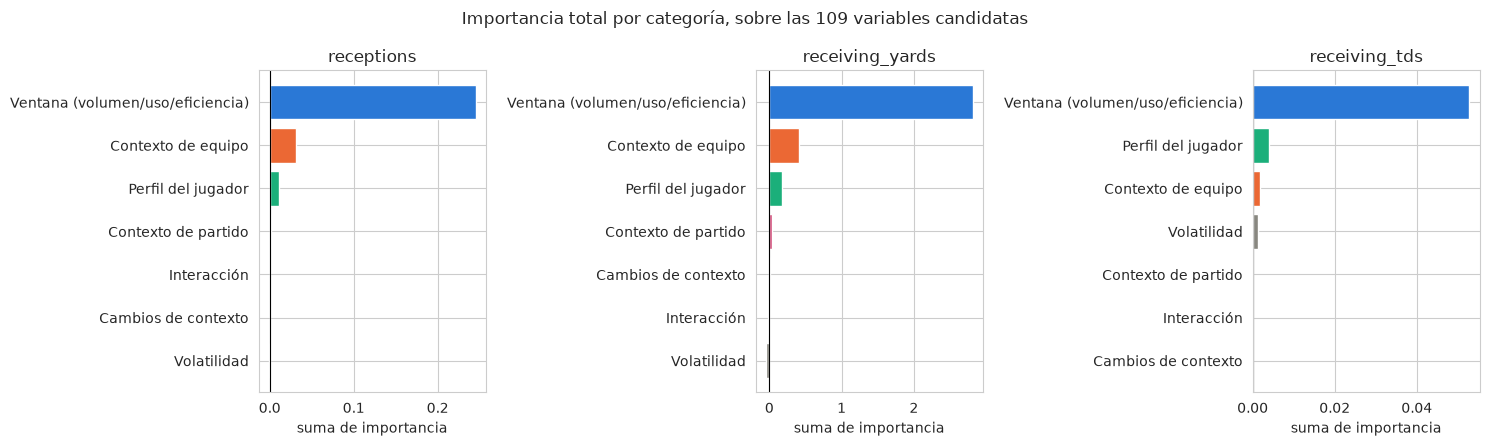

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, TARGETS):
    valores = resumen_categoria[target].sort_values()
    colores = [colores_categoria[c] for c in valores.index]
    ax.barh(valores.index, valores.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(target)
    ax.set_xlabel("suma de importancia")
fig.suptitle("Importancia total por categoría, sobre las 109 variables candidatas")
plt.tight_layout()
plt.show()

**Cada panel tiene su propia escala** — a propósito: si se usara la misma escala para los 3, el
panel de `receiving_tds` se vería completamente plano (sus valores son 10-100x más chicos), y esa
diferencia de magnitud es en sí misma un hallazgo (target difícil de explicar con cualquier
variable, no solo con las que se probaron). Dentro de cada panel, la lectura sí es comparable:
**Ventana** domina con claridad en los 3, **Contexto de equipo** es un segundo lugar consistente
(gracias casi por completo a `depth_team`), y **Perfil del jugador** aporta un tercer lugar
modesto pero real. **Volatilidad**, **Cambios de contexto**, **Contexto de partido** e
**Interacción** quedan pegadas a cero en los 3 — visualmente confirma lo ya dicho en la sección 6:
se probaron de buena fe, no se confirmaron.

Ahora las variables individuales top 10 de cada target, coloreadas por su categoría — la misma
información de la tabla de 4.2, pero de un vistazo, y mostrando que dentro de "Ventana" no todas
las variables valen lo mismo.

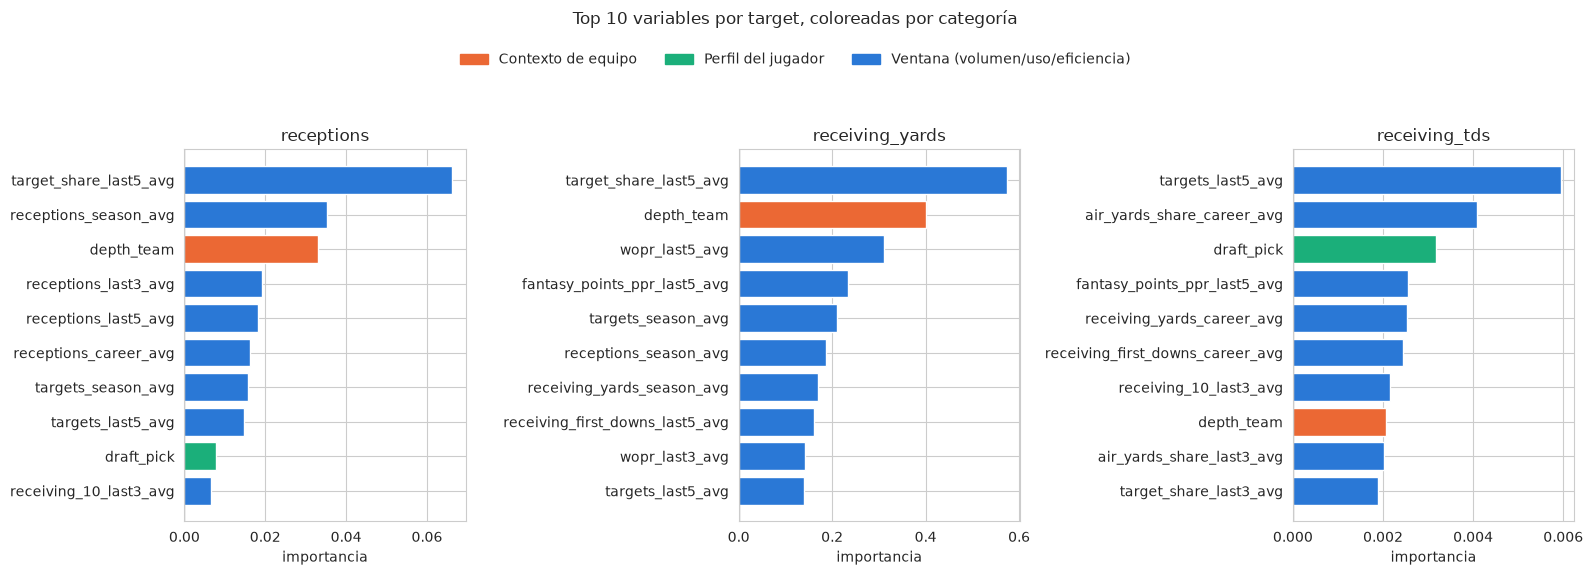

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target in zip(axes, TARGETS):
    top = resultados[target].head(10).sort_values()
    colores = [colores_categoria[categoria(c)] for c in top.index]
    ax.barh(top.index, top.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(target)
    ax.set_xlabel("importancia")

categorias_presentes = sorted({categoria(c) for t in TARGETS for c in resultados[t].head(10).index})
handles = [plt.Rectangle((0, 0), 1, 1, color=colores_categoria[c]) for c in categorias_presentes]
fig.legend(handles, categorias_presentes, loc="upper center", ncol=len(categorias_presentes),
           bbox_to_anchor=(0.5, 1.08), frameon=False)
fig.suptitle("Top 10 variables por target, coloreadas por categoría", y=1.14)
plt.tight_layout()
plt.show()

En los 3 targets, el top 10 sale casi por completo de **Ventana** (azul) — `depth_team`
(naranja) es la única variable de **Contexto de equipo** que se cuela consistentemente, y
`draft_pick` (verde, **Perfil del jugador**) aparece en `receiving_yards` y `receiving_tds` pero
no alcanza el top 10 de `receptions`. Ninguna variable de volatilidad, cambios de contexto,
contexto de partido o interacción aparece en ningún top 10 — coherente con el panorama agregado de
arriba.

## 5. `last3` vs. `last5` vs. `season` vs. `career` — con evidencia de modelo, en los 3 targets

Esto es lo que `08_eda_multivariable.ipynb` dejó abierto a propósito: la correlación aislada
mostraba a `last3` como la más débil de las 4, por un margen pequeño (2-3 puntos), insuficiente
para decidir. Aquí se suma la importancia de todas las variables de cada ventana, para cada
target — la pregunta ya no es "cuál correlaciona más sola" sino "cuál aporta más una vez que el
modelo ya tiene acceso a las demás".

In [13]:
resumen_ventanas = {}
for suf, nombre in [("_last3_avg", "last3"), ("_last5_avg", "last5"), ("_season_avg", "season"), ("_career_avg", "career")]:
    fila = {}
    for target in TARGETS:
        cols = [c for c in X.columns if c.endswith(suf)]
        fila[target] = resultados[target][cols].sum()
    resumen_ventanas[nombre] = fila

pd.DataFrame(resumen_ventanas).T.round(3)

,receptions,receiving_yards,receiving_tds
last3,0.054,0.374,0.012
last5,0.100,1.558,0.014
season,0.062,0.852,0.011
career,0.028,0.034,0.015


**`last5` gana con claridad en los 3 targets** — no por un margen pequeño como en la correlación
aislada, sino de forma consistente y amplia. `season_avg` es un complemento real, no redundante:
en yardas queda en segundo lugar, por encima incluso de `last3`. `last3` sigue aportando algo,
pero menos que las otras dos. La sorpresa real: **`career_avg`, que por correlación aislada
(Fase 3) se veía tan fuerte como `last5`, resulta el más débil de los 4 una vez evaluado junto a
los demás** — no es que "no sirva" por sí sola, es que la información que aporta ya la cubren
`last5`/`season` cuando están presentes al mismo tiempo. Es la misma lección que ya dejó la edad
en Fase 3, en dirección contraria: una correlación aislada y una evaluación conjunta pueden
contar historias distintas, y la conjunta es la que de verdad importa para elegir features de un
modelo.

**Decisión**: `last5_avg` y `season_avg` como ventanas prioritarias para Fase 5, en los 3 targets.
`last3_avg` se conserva como variable secundaria (aporta, aunque menos). `career_avg` se conserva
en `features.py` — sigue siendo útil para otros análisis — pero no se prioriza en el feature set
de modelado.

## 6. El resto de las variables nuevas — resultado honesto, no solo las que funcionaron

In [14]:
otras = ["depth_team", "draft_pick", "edad", "anios_experiencia",
         "receiving_yards_volatilidad5", "targets_volatilidad5",
         "cambio_qb_titular_num", "cambio_equipo_num", "rest", "div_game",
         "target_share_x_ofensiva_equipo", "draft_pick_x_experiencia", "cambio_qb_x_target_share"]
tabla_otras = pd.DataFrame({t: resultados[t].reindex(otras) for t in TARGETS})
tabla_otras.round(4)

,receptions,receiving_yards,receiving_tds
depth_team,0.0329,0.4015,0.0021
draft_pick,0.0079,0.0807,0.0032
edad,0.0031,0.0665,0.0006
anios_experiencia,0.0002,0.0174,0.0002
receiving_yards_volatilidad5,-0.0013,-0.0290,-0.0000
targets_volatilidad5,0.0004,-0.0174,0.0012
cambio_qb_titular_num,0.0000,0.0044,0.0001
cambio_equipo_num,0.0000,0.0000,-0.0000
rest,0.0003,-0.0045,0.0001
div_game,0.0001,-0.0024,0.0000


- **`depth_team` cierra el hueco real de Fase 3**: nunca se había probado, y resulta de las
  variables más fuertes para recepciones y yardas (segundo lugar general en yardas) — el lugar de
  un receptor en la alineación de su equipo importa, y de forma sustancial. Entra al feature set,
  con su limitación documentada: 0% de cobertura en 2025 en adelante hasta que se resuelva la
  unificación de esquemas de `depth_charts` (pospuesta desde Fase 2) — ahora con evidencia real de
  que vale la pena resolverla antes de producción.
- **`draft_pick` y `edad`/`anios_experiencia`** confirman, con evidencia de modelo y no solo de
  correlación, lo que Fase 3 ya sugería — entran al feature set.
- **La volatilidad reciente (desviación estándar de las últimas 5 apariciones) no muestra
  evidencia de aportar** — importancia nula o negativa en los 3 targets. Era una idea razonable
  (medir consistencia, no solo nivel) pero no se confirma con datos — no entra al feature set por
  ahora.
- **Ninguna de las 3 interacciones propuestas muestra un aporte claro** — `target_share` ×
  ofensiva de equipo incluso sale negativa en yardas. Se probaron con una razón concreta cada una,
  y ninguna se confirmó — no entran al feature set.
- **Cambio de QB titular y cambio de equipo aportan casi nada una vez que el modelo ya tiene
  features de uso reciente** (`target_share_last5_avg`, etc.) — un resultado honesto que matiza,
  no contradice, el hallazgo de `08_eda_multivariable.ipynb`: el efecto de un cambio de QB
  probablemente ya se refleja en la caída de uso reciente del receptor, no es una señal
  independiente adicional. No entran al feature set principal — quedan documentadas como
  hipótesis probada y no confirmada, no como error.
- **`rest` y `div_game`, calculados en Fase 3 pero nunca interpretados, cierran su hueco: sin
  evidencia de aportar** en ningún target — no entran al feature set.

## 7. Tabla final — variable, qué es, evidencia y decisión

Primero el detalle, categorizado, incluyendo las variables individuales que la sección 4.2 mostró
que sí importan por separado (no solo como parte del agregado de su ventana):

| Categoría | Variable | Qué es | Evidencia real (yardas · recepciones · TDs) | Conclusión |
|---|---|---|---|---|
| Ventana | `target_share`/`wopr`/`air_yards_share`/`receiving_epa` (`last5`/`season`) | Qué tanto del trabajo de pase del equipo recae en el jugador (participación + eficiencia), resumido en sus últimos 5 partidos o en la temporada | Máxima importancia conjunta en los 3 targets | **Incluir, prioritarias** |
| Ventana | `fantasy_points_ppr` (`last5`) | Puntaje estándar de fantasy football (PPR) de esa semana — resume todo el desempeño en un solo número | 0.235 · — · 0.0025 | Incluir — nueva, nombrada individualmente en 4.2 |
| Ventana | `receiving_first_downs` (`last5`/`career`) | Recepciones que lograron una primera oportunidad (mueven las cadenas) | 0.161 · — · 0.0024 | Incluir — nueva |
| Ventana | `air_yards_share` (`season`/`career`) | % del total de yardas aéreas del equipo que le corresponden a este jugador | 0.096 · — · 0.0041 | Incluir — nueva |
| Ventana | `receiving_air_yards` (`season`) | Yardas totales que viajó el balón en el aire hacia este jugador (profundidad × volumen) | 0.073 · — · — | Incluir — nueva |
| Ventana | `receiving_epa` (`last3`) | Valor esperado de puntos que generan sus recepciones (métrica avanzada de eficiencia) | — · 0.0065 · — | Incluir — nueva, específica de recepciones |
| Ventana | `receiving_10`/`receiving_20` (`last3`) | Conteo de recepciones de más de 10/20 yardas (jugadas de valor) | — · 0.0066/0.0045 · 0.0022 | Incluir — nueva |
| Ventana | `catch_rate` (`career`) / `receiving_16` (`last5`) / `receiving_tds` (`season`) | % de targets atrapados / recepciones de más de 16 yardas / touchdowns propios de la temporada, rezagados | — · — · 0.0017-0.0019 | Incluir, aporte marginal en TDs |
| Ventana | Resto de columnas de uso/rendimiento (`last5`/`season`) | Volumen propio del jugador (recepciones, yardas, targets) | Importancia real en los 3 (sección 5) | Incluir |
| Ventana | `last3` (todas las columnas) | Promedio de los últimos 3 partidos | Aporta, menos que `last5`/`season` en los 3 targets (sección 5) | Incluir, secundaria |
| Ventana | `career` (todas las columnas) | Promedio de toda la carrera del jugador | La más débil de las 4 en conjunto, pese a buena correlación aislada en Fase 3 (sección 5) | Conservar en `features.py`, no priorizar en modelado |
| Ventana | `target_share`/`air_yards_share`/`wopr` juntas en Ridge | Las 3 miden participación del jugador, muy correlacionadas entre sí | Colinealidad 0.82-0.97 (Fase 3) | Usar `columnas_por_modelo("ridge")` (solo `wopr`+`receiving_epa`) |
| Contexto de equipo | `depth_team` | Su lugar en la alineación del equipo (1=titular/WR1, 2=WR2...) — más bajo es mejor | 0.402 · 0.033 · 0.002 — 2º lugar general en yardas | **Incluir** — cierra el hueco de Fase 3, nunca antes probado; 0% cobertura en 2025+ hasta unificar esquemas |
| Perfil del jugador | `draft_pick` | En qué número fue seleccionado en el draft (más bajo = elegido antes); al no drafteado se le asigna peor que el último pick real | 0.081 · 0.008 · 0.003 | Incluir |
| Perfil del jugador | `edad` / `anios_experiencia` (+ `_sq`/`_bucket` para lineales) | Edad esa temporada / cuántas temporadas lleva en la NFL | 0.067/0.017 · ~0 · ~0 | Incluir; transformación no lineal específica para Ridge |
| Ventana | `racr_acotado` | Eficiencia de conversión de yardas aéreas, con tope para evitar valores extremos | Sin destacar en la evaluación conjunta | Se mantiene calculado, sin evidencia de aporte fuerte |
| Volatilidad | `_volatilidad5` | Qué tan parejo o irregular fue en sus últimas 5 apariciones (alta = boom-bust) | -0.029 · -0.001 · -0.000 (negativo) | **No incluir** por ahora |
| Cambios de contexto | `cambio_qb_titular` / `cambio_equipo` | Si cambió el QB titular de su equipo, o si el jugador cambió de equipo, respecto a su aparición anterior | 0.004 · 0.000 · 0.000 | No incluir en el set principal — casi nulo con uso reciente ya presente |
| Interacción | `target_share_x_ofensiva_equipo`, `draft_pick_x_experiencia`, `cambio_qb_x_target_share` | Combinan 2 variables ya existentes (uso × ofensiva de equipo, draft × experiencia, cambio de QB × uso) | -0.024/0.002/0.011 en yardas, ~0 en el resto | No incluir — sin aporte claro, una incluso negativa |
| Contexto de partido | Dureza defensiva del rival, Vegas/clima, acarreos de WR | Qué tan dura es la defensa rival; puntos esperados por casas de apuestas y clima; jugadas de carrera de un WR | Sin efecto, confirmado en Fase 3 | No incluir, no reevaluado aquí sin razón nueva |
| Contexto de partido | `rest` / `div_game` | Días de descanso / si el partido es contra un rival de la misma división | ~0 en los 3 | No incluir |
| — | Filas sin ningún target esa semana (`targets == 0`) | — | Afecta la elección de función de pérdida (Poisson/Tweedie ya sugerido en `05_eda_perfil_variables.ipynb`) | Decisión de modelado, no de features — se deja para Fase 5 |

Versión compacta (la que vive también en el docstring de módulo de `weekly/wr/src/features.py`,
el entregable que pide `docs/PLAN.md` para esta fase):

| Variable | Decisión | Evidencia |
|---|---|---|
| `target_share`/`wopr`/`air_yards_share`/`receiving_epa`/`fantasy_points_ppr`/`receiving_first_downs` (`last5`/`season`) | Incluir, prioritarias | Máxima importancia conjunta en los 3 targets (secciones 4.2 y 5) |
| Resto de columnas de uso/rendimiento (`last5`/`season`) | Incluir | Mismo patrón, importancia real (sección 5) |
| Ventana `last3` | Incluir, secundaria | Aporta menos que `last5`/`season` en los 3 targets (sección 5) |
| Ventana `career` | Conservar, no priorizar en modelado | Redundante frente a `last5`+`season` en conjunto, pese a buena correlación aislada en Fase 3 (sección 5) |
| `target_share`/`air_yards_share`/`wopr` juntas en Ridge | Usar `columnas_por_modelo("ridge")` | Colinealidad 0.82-0.97 (Fase 3) |
| `depth_team` | Incluir | Señal fuerte y nueva en recepciones/yardas (sección 4.2); 0% cobertura en 2025+ hasta unificar esquemas |
| `draft_pick` | Incluir (imputado: peor pick real + 1) | Confirmado con evidencia de modelo, no solo correlación (sección 4.2) |
| `edad` / `anios_experiencia` (+ `_sq`/`_bucket` para lineales) | Incluir | Confirmado con evidencia de modelo (sección 4.2); transformación no lineal específica para Ridge |
| `racr_acotado` | Se mantiene calculado, sin evidencia fuerte | No destacó en la evaluación conjunta |
| Volatilidad reciente (`_volatilidad5`) | No incluir por ahora | Importancia nula/negativa en los 3 targets (sección 6) |
| `cambio_qb_titular` / `cambio_equipo` | No incluir en el feature set principal | Aporte marginal casi nulo con uso reciente ya presente (sección 6) — matiza, no invalida, el hallazgo bivariado de Fase 3 |
| Interacciones (`target_share_x_ofensiva_equipo`, `draft_pick_x_experiencia`, `cambio_qb_x_target_share`) | No incluir | Sin aporte claro, una incluso negativa (sección 6) |
| Dureza defensiva del rival, Vegas/clima, acarreos de WR | No incluir | Confirmado sin efecto en Fase 3, no reevaluado sin razón nueva |
| `rest` / `div_game` | No incluir | Sin evidencia de aportar (sección 6) |
| Filas sin ningún target esa semana (`targets == 0`) | Decisión de modelado, no de features — se deja para Fase 5 | Afecta la función de pérdida (Poisson/Tweedie), no qué columnas usar |

## Cierre

Quedan resueltas, con evidencia real y no solo de correlación: la pregunta de `last3` vs. `last5`
(gana `last5`, `season` es un complemento real, `career` resulta redundante en conjunto), el hueco
de `depth_chart` nunca antes probado (aporta, con una limitación de cobertura ya documentada), y
el hueco de `rest`/`div_game` calculados pero nunca interpretados (no aportan). Tres ideas nuevas
—volatilidad reciente y las 3 interacciones propuestas— se probaron de buena fe y no se
confirmaron; quedan documentadas como intentos razonables sin evidencia a favor, no como errores.

La sección 4.2 fue más allá de agrupar por ventana: al ver la unión de las 15 variables más
importantes de cada target, aparecieron individualmente `fantasy_points_ppr`,
`receiving_first_downs`, `air_yards_share`, `receiving_air_yards`, `receiving_epa` y los conteos
de recepciones largas (`receiving_10`/`16`/`20`) — todas ya estaban dentro de las 109 candidatas,
pero solo como parte del agregado de su ventana. Se nombran aparte y entran explícitas a la Tabla
final (sección 7) porque la evidencia real las señala como contribuyentes individuales, no solo
miembros de un grupo genérico.

Lo que sigue es Fase 5: con este feature set ya seleccionado, comparar Baseline/Ridge/RandomForest/
XGBoost con split temporal, y ahí sí decidir cómo tratar las semanas sin target (Poisson/Tweedie
vs. filtrar).

Notebook anterior: [`10_ingenieria_features.ipynb`](10_ingenieria_features.ipynb) — último de la Fase 4.